In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from main.classes.neural_networks.training.train_arimaema import train_and_evaluate_arima, load_data
from main.classes.neural_networks.training.train_arima import  (
    train_and_evaluate_arima,
    load_series,
    split_series
)


In [5]:
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
os.makedirs(model_dir, exist_ok=True)

df = load_data(csv_path)

target = 'ITUB4'

In [6]:
try:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, target, order, model_dir, version, split_date,rolling,step_size)
    
    print(f"\nMétricas do modelo ARIMA para {target}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
except Exception as e:
    print(f"Erro durante o treinamento: {e}")


2025-06-25 10:59:57,845 - INFO - Carregando dados para ITUB4
2025-06-25 10:59:57,902 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-25 11:02:55,190 - INFO - 
Métricas no conjunto de teste:
2025-06-25 11:02:55,191 - INFO - MSE: 0.2386
2025-06-25 11:02:55,191 - INFO - RMSE: 0.4884
2025-06-25 11:02:55,192 - INFO - MAE: 0.3503
2025-06-25 11:02:55,192 - INFO - R2: 0.9806
2025-06-25 11:02:55,235 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima



Métricas do modelo ARIMA para ITUB4:
MSE: 0.2386
RMSE: 0.4884
MAE: 0.3503
R2: 0.9806


In [5]:
# Carregar os valores reais e previstos
test_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy"))
predicted_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy"))

# Obter as datas corretas
test_series = df[target].dropna()
test_dates = test_series.index[-len(test_values):]

In [15]:
# Recuperar a série completa para alinhar o y_true
full_series = df[target].dropna()
y_true = full_series[-len(predictions):]

# Caminhos dos arquivos
y_true_path = os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy")
y_pred_path = os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy")

# Salvar os arquivos .npy
np.save(y_true_path, y_true)
np.save(y_pred_path, predictions)

print(f"Valores salvos:\n- {y_true_path}\n- {y_pred_path}")

Valores salvos:
- ../../saved_models/regressao\ITUB4_arima_rolling_y_true_vv1.0.npy
- ../../saved_models/regressao\ITUB4_arima_rolling_y_pred_vv1.0.npy


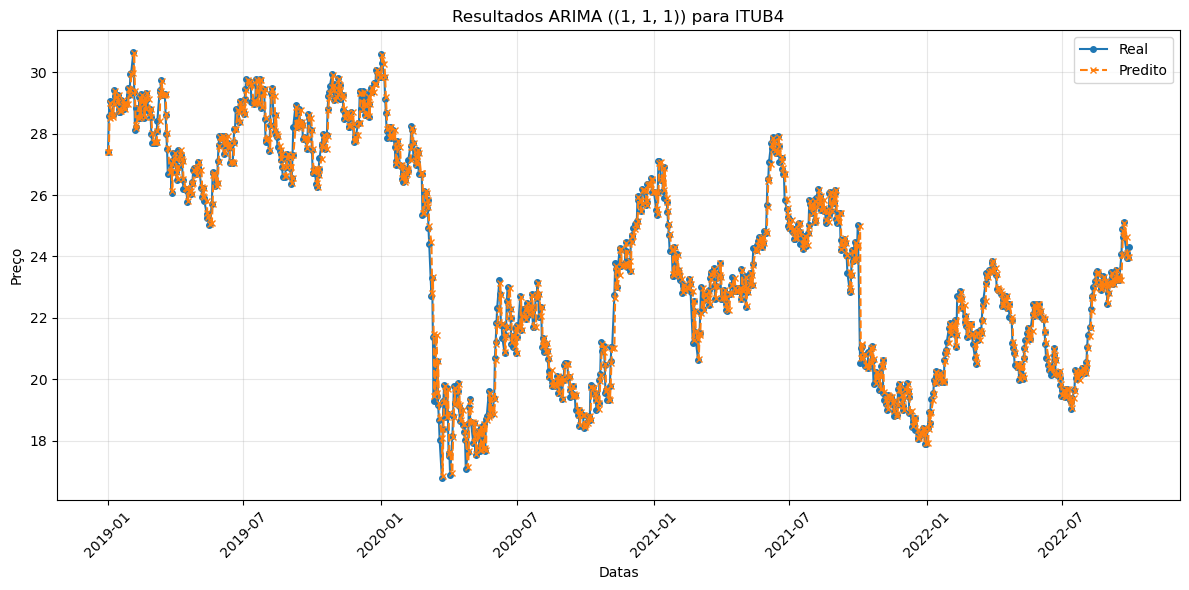

In [6]:
# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(test_dates, test_values, label='Real', marker='o', markersize=4)
plt.plot(test_dates, predicted_values, label='Predito', linestyle='--', marker='x', markersize=4)

plt.title(f"Resultados ARIMA ({order}) para {target}")
plt.xlabel('Datas')
plt.ylabel('Preço')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt

# Configurações básicas
acoes =['ITUB4', 'BBAS3', 'CYRE3', 'TEND3' ,'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
# Dicionário para armazenar os resultados
resultados_arima = {}
dates_map = {}

# Executa para cada ação
for acao in acoes:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, acao, order, model_dir, version, split_date, rolling,step_size)
    y_test = np.load(f"{model_dir}/{acao}_arima_rolling_y_true_v{version}.npy")
    resultados_arima[acao] = (y_test, predictions)

    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df = df.set_index('Date')
    df = df[df.index >= "2019-01-07"]
    dates_map[acao] = df.index[:len(y_test)]
        # Salva y_true e y_pred como .npy
        # Recupera valores reais do teste (mesmo número de pontos das previsões)
    serie = df[acao].dropna()
    y_true = serie[-len(predictions):]    
    np.save(f"{model_dir}/{acao}_arima_rolling_y_true_v{version}.npy", y_true)
    np.save(f"{model_dir}/{acao}_arima_rolling_y_pred_v{version}.npy", predictions)
# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=False)

for i, acao in enumerate(acoes):
    y_test, predictions = resultados_arima[acao]
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    # Obtem a série alvo completa (com datas)
    test_series = df[acao].dropna()
    test_dates = test_series.index[-len(y_test):]

    dates_map[acao] = test_dates
    axes[i].plot(test_dates, y_test, label=f'Real {acao}')
    axes[i].plot(test_dates, predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()


2025-06-17 23:46:16,192 - INFO - Carregando dados para ITUB4
2025-06-17 23:46:16,236 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


KeyboardInterrupt: 

Parte da Regressão Linear para Gerar A comparação entre os 3.

In [4]:
import os
import sys
sys.path.append(os.path.abspath("../../"))

# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
from classes.neural_networks.training.train_linear_regression import train_and_evaluate, load_data
# Define os parâmetros
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
window = 3
model_dir = "../../saved_models/regressao"
version = "v1.0"
# Carrega os dados para obter as datas
df = load_data(csv_path)
df.sort_values("Date", inplace=True)
dates = df['Date'].values
target = "ITUB4"

2025-06-24 22:14:42,138 - INFO - Carregando dados do CSV para a ação ITUB4
2025-06-24 22:14:42,160 - INFO - Normalizando dados
2025-06-24 22:14:42,164 - INFO - Treinando modelo usando a equação normal
2025-06-24 22:14:42,398 - INFO - Desnormalizando previsões
2025-06-24 22:14:42,400 - INFO - Avaliando modelo
2025-06-24 22:14:42,404 - INFO - 
Métricas de Treino:
2025-06-24 22:14:42,405 - INFO - MSE: 0.0539
2025-06-24 22:14:42,405 - INFO - RMSE: 0.2322
2025-06-24 22:14:42,406 - INFO - MAE: 0.1657
2025-06-24 22:14:42,407 - INFO - R2: 0.9960
2025-06-24 22:14:42,407 - INFO - 
Métricas de Validação:
2025-06-24 22:14:42,408 - INFO - MSE: 0.2061
2025-06-24 22:14:42,408 - INFO - RMSE: 0.4540
2025-06-24 22:14:42,408 - INFO - MAE: 0.3501
2025-06-24 22:14:42,409 - INFO - R2: 0.9564
2025-06-24 22:14:42,410 - INFO - 
Métricas de Teste:
2025-06-24 22:14:42,410 - INFO - MSE: 0.2499
2025-06-24 22:14:42,410 - INFO - RMSE: 0.4999
2025-06-24 22:14:42,411 - INFO - MAE: 0.3664
2025-06-24 22:14:42,412 - INFO

Parâmetros do modelo: [4.38040627e-04 9.88015060e-01 2.99275995e-03 8.74488947e-03]
Métricas de Treino: {'MSE': 0.05393999672719481, 'RMSE': 0.2322498584008068, 'MAE': 0.16566143115191387, 'R2': 0.9959842642392567}
Métricas de Validação: {'MSE': 0.20614253857874376, 'RMSE': 0.4540292265688892, 'MAE': 0.35013730610511673, 'R2': 0.9563970908989935}
Métricas de Teste: {'MSE': 0.2498567452803604, 'RMSE': 0.4998567247525639, 'MAE': 0.3663662416365265, 'R2': 0.9794705355745817}


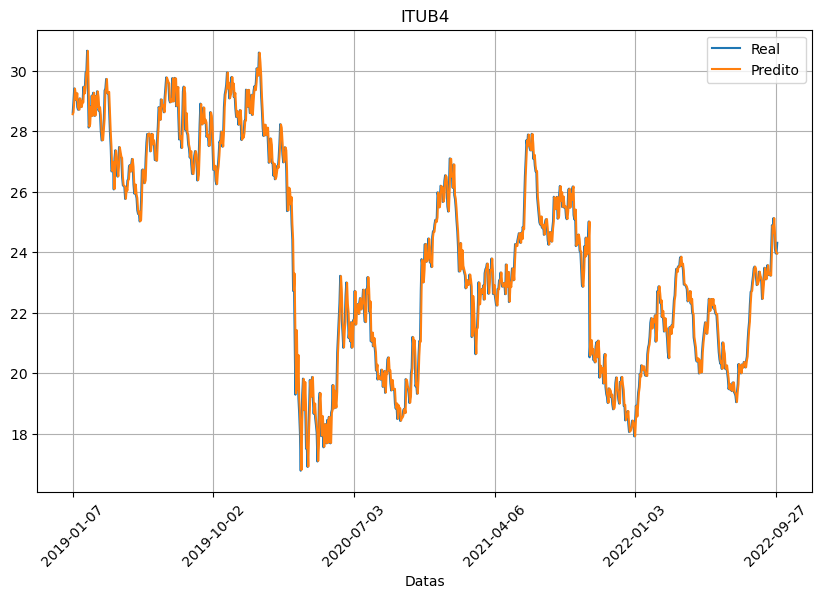

In [5]:
# Chama a função para treinar e avaliar o modelo
model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, target, window,model_dir, version)

# Exibe os parâmetros do modelo e as métricas de treino, validação e teste
print("Parâmetros do modelo:", theta)
print("Métricas de Treino:", train_metrics)
print("Métricas de Validação:", val_metrics)
print("Métricas de Teste:", test_metrics)

# Visualiza os resultados
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Real')
plt.plot(test_predictions, label='Predito',)

# Adiciona as datas no eixo x
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
plt.xticks(ticks=range(0, num_dates, step), labels=dates[-num_dates::step], rotation=45)

plt.title(target)
plt.xlabel('Datas')
plt.grid(True)
plt.legend()
plt.show()

2025-06-24 22:14:44,750 - INFO - Carregando dados do CSV para a ação CMIG4
2025-06-24 22:14:44,780 - INFO - Normalizando dados
2025-06-24 22:14:44,782 - INFO - Treinando modelo usando a equação normal
2025-06-24 22:14:44,783 - INFO - Desnormalizando previsões
2025-06-24 22:14:44,784 - INFO - Avaliando modelo
2025-06-24 22:14:44,788 - INFO - 
Métricas de Treino:
2025-06-24 22:14:44,788 - INFO - MSE: 0.0034
2025-06-24 22:14:44,789 - INFO - RMSE: 0.0584
2025-06-24 22:14:44,790 - INFO - MAE: 0.0404
2025-06-24 22:14:44,790 - INFO - R2: 0.9902
2025-06-24 22:14:44,791 - INFO - 
Métricas de Validação:
2025-06-24 22:14:44,791 - INFO - MSE: 0.0041
2025-06-24 22:14:44,791 - INFO - RMSE: 0.0639
2025-06-24 22:14:44,792 - INFO - MAE: 0.0450
2025-06-24 22:14:44,792 - INFO - R2: 0.9848
2025-06-24 22:14:44,793 - INFO - 
Métricas de Teste:
2025-06-24 22:14:44,794 - INFO - MSE: 0.0093
2025-06-24 22:14:44,795 - INFO - RMSE: 0.0966
2025-06-24 22:14:44,795 - INFO - MAE: 0.0707
2025-06-24 22:14:44,796 - INFO

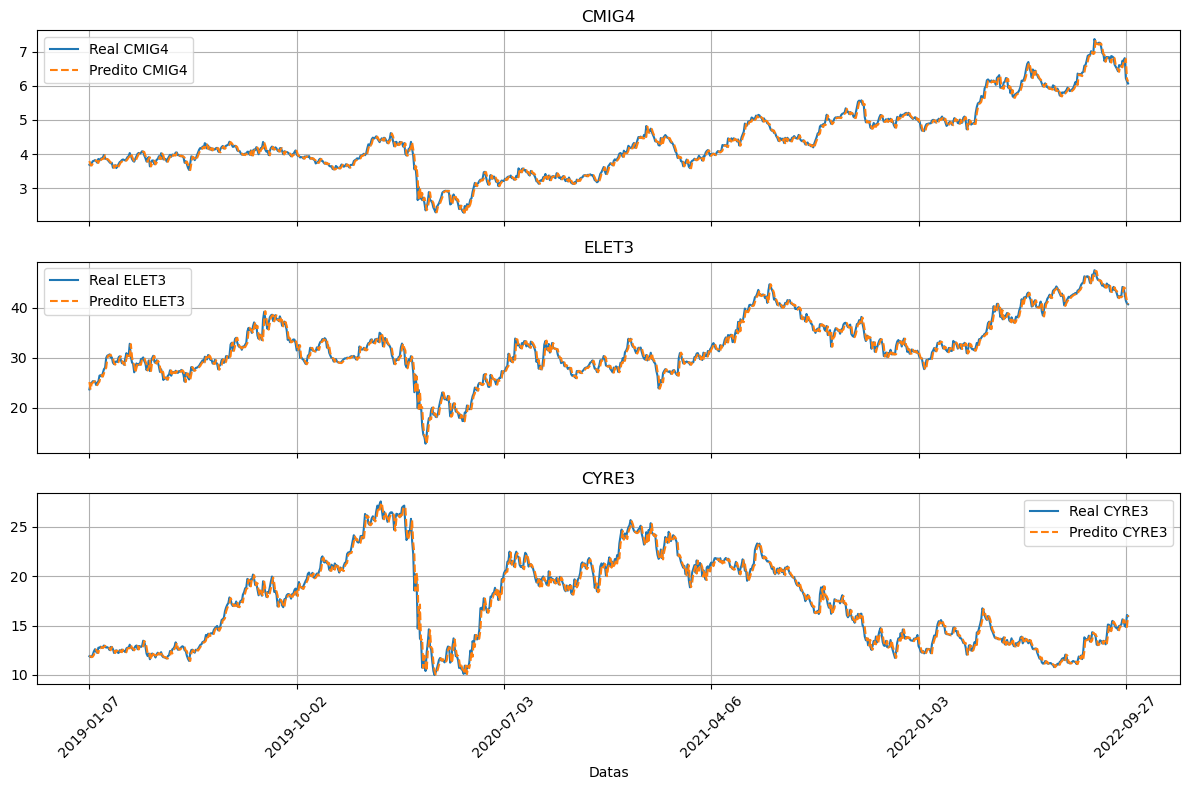

In [6]:
# Lista de ações a serem analisadas
acoes = ["CMIG4", "ELET3", "CYRE3",]

# Dicionário para armazenar os resultados
resultados = {}

# Treina e avalia o modelo para cada ação
for acao in acoes:
    model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, acao, window,model_dir, version)
    resultados[acao] = (y_test, test_predictions)

# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=True)

for i, acao in enumerate(acoes):
    y_test, test_predictions = resultados[acao]
    axes[i].plot(y_test, label=f'Real {acao}')
    axes[i].plot(test_predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

# Adiciona as datas no eixo x do último subplot
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
axes[-1].set_xticks(range(0, num_dates, step))
axes[-1].set_xticklabels(dates[-num_dates::step], rotation=45)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()

2025-06-18 22:30:35,896 - INFO - Carregando dados do CSV para a ação ITUB4
2025-06-18 22:30:35,914 - INFO - Normalizando dados
2025-06-18 22:30:35,916 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:30:35,917 - INFO - Desnormalizando previsões
2025-06-18 22:30:35,918 - INFO - Avaliando modelo
2025-06-18 22:30:35,921 - INFO - 
Métricas de Treino:
2025-06-18 22:30:35,922 - INFO - MSE: 0.0539
2025-06-18 22:30:35,922 - INFO - RMSE: 0.2322
2025-06-18 22:30:35,923 - INFO - MAE: 0.1657
2025-06-18 22:30:35,924 - INFO - R2: 0.9960
2025-06-18 22:30:35,924 - INFO - 
Métricas de Validação:
2025-06-18 22:30:35,925 - INFO - MSE: 0.2061
2025-06-18 22:30:35,925 - INFO - RMSE: 0.4540
2025-06-18 22:30:35,926 - INFO - MAE: 0.3501
2025-06-18 22:30:35,927 - INFO - R2: 0.9564
2025-06-18 22:30:35,927 - INFO - 
Métricas de Teste:
2025-06-18 22:30:35,928 - INFO - MSE: 0.2499
2025-06-18 22:30:35,929 - INFO - RMSE: 0.4999
2025-06-18 22:30:35,929 - INFO - MAE: 0.3664
2025-06-18 22:30:35,930 - INFO


Processando: ITUB4


c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-18 22:33:31,066 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:33:31,067 - INFO - MSE: 0.2386
2025-06-18 22:33:31,067 - INFO - RMSE: 0.4884
2025-06-18 22:33:31,068 - INFO - MAE: 0.3503
2025-06-18 22:33:31,069 - INFO - R2: 0.9806
2025-06-18 22:33:31,111 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:33:31,114 - INFO - Carregando dados para ITUB4
2025-06-18 22:33:31,154 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 9


Métricas do modelo ARIMA para ITUB4:
MSE: 0.2386
RMSE: 0.4884
MAE: 0.3503
R2: 0.9806


2025-06-18 22:33:31,658 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:33:31,659 - INFO - MSE: 24.1392
2025-06-18 22:33:31,659 - INFO - RMSE: 4.9132
2025-06-18 22:33:31,660 - INFO - MAE: 4.0273
2025-06-18 22:33:31,661 - INFO - R2: -0.9676
2025-06-18 22:33:31,707 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


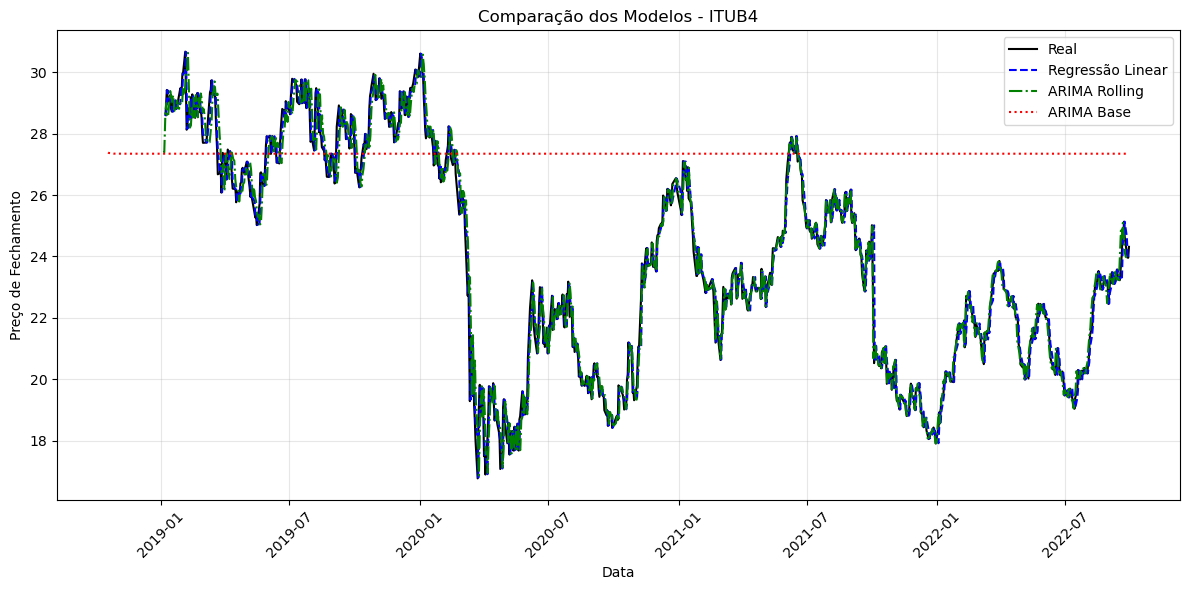

2025-06-18 22:33:31,939 - INFO - Carregando dados do CSV para a ação BBAS3
2025-06-18 22:33:31,956 - INFO - Normalizando dados
2025-06-18 22:33:31,959 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:33:31,961 - INFO - Desnormalizando previsões
2025-06-18 22:33:31,962 - INFO - Avaliando modelo
2025-06-18 22:33:31,966 - INFO - 
Métricas de Treino:
2025-06-18 22:33:31,967 - INFO - MSE: 0.0281
2025-06-18 22:33:31,967 - INFO - RMSE: 0.1676
2025-06-18 22:33:31,968 - INFO - MAE: 0.1158
2025-06-18 22:33:31,968 - INFO - R2: 0.9899
2025-06-18 22:33:31,969 - INFO - 
Métricas de Validação:
2025-06-18 22:33:31,970 - INFO - MSE: 0.0835
2025-06-18 22:33:31,970 - INFO - RMSE: 0.2890
2025-06-18 22:33:31,971 - INFO - MAE: 0.2225
2025-06-18 22:33:31,971 - INFO - R2: 0.9770
2025-06-18 22:33:31,972 - INFO - 
Métricas de Teste:
2025-06-18 22:33:31,972 - INFO - MSE: 0.1167
2025-06-18 22:33:31,973 - INFO - RMSE: 0.3416
2025-06-18 22:33:31,974 - INFO - MAE: 0.2373
2025-06-18 22:33:31,974 - INFO


Processando: BBAS3


2025-06-18 22:36:24,301 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:36:24,301 - INFO - MSE: 0.1114
2025-06-18 22:36:24,302 - INFO - RMSE: 0.3337
2025-06-18 22:36:24,302 - INFO - MAE: 0.2261
2025-06-18 22:36:24,303 - INFO - R2: 0.9834
2025-06-18 22:36:24,344 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:36:24,348 - INFO - Carregando dados para BBAS3
2025-06-18 22:36:24,390 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para BBAS3:
MSE: 0.1114
RMSE: 0.3337
MAE: 0.2261
R2: 0.9834


2025-06-18 22:36:24,638 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:36:24,639 - INFO - MSE: 8.3414
2025-06-18 22:36:24,640 - INFO - RMSE: 2.8882
2025-06-18 22:36:24,640 - INFO - MAE: 2.5566
2025-06-18 22:36:24,641 - INFO - R2: -0.2448
2025-06-18 22:36:24,678 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


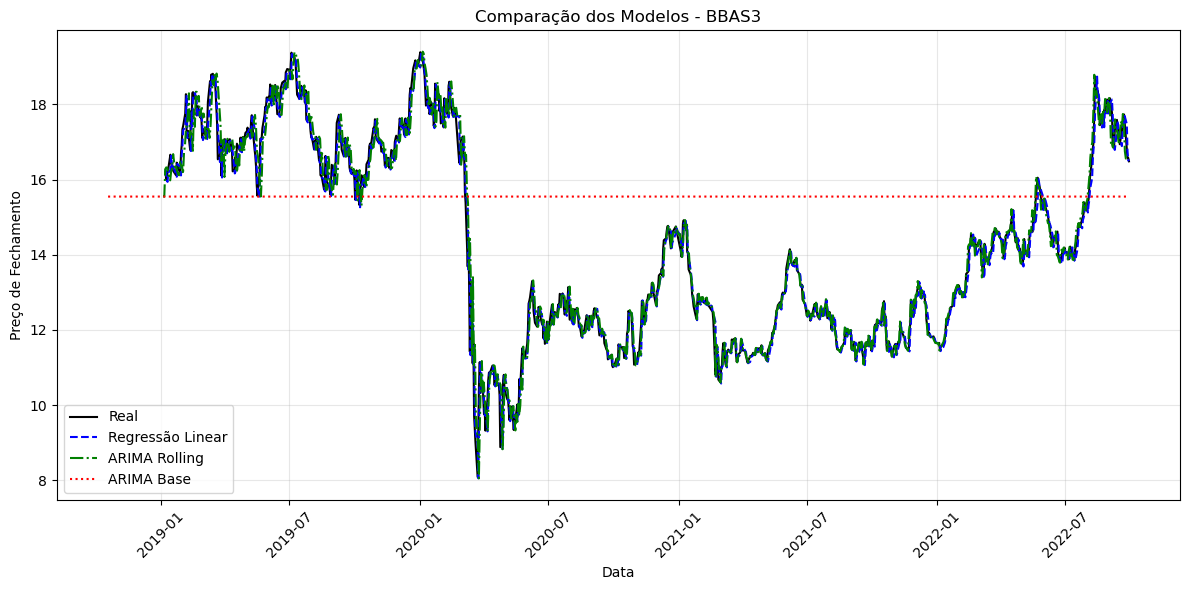

2025-06-18 22:36:24,896 - INFO - Carregando dados do CSV para a ação CYRE3
2025-06-18 22:36:24,912 - INFO - Normalizando dados
2025-06-18 22:36:24,915 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:36:24,916 - INFO - Desnormalizando previsões
2025-06-18 22:36:24,917 - INFO - Avaliando modelo
2025-06-18 22:36:24,922 - INFO - 
Métricas de Treino:
2025-06-18 22:36:24,923 - INFO - MSE: 0.0506
2025-06-18 22:36:24,924 - INFO - RMSE: 0.2249
2025-06-18 22:36:24,925 - INFO - MAE: 0.1641
2025-06-18 22:36:24,925 - INFO - R2: 0.9897
2025-06-18 22:36:24,926 - INFO - 
Métricas de Validação:
2025-06-18 22:36:24,927 - INFO - MSE: 0.0456
2025-06-18 22:36:24,928 - INFO - RMSE: 0.2135
2025-06-18 22:36:24,928 - INFO - MAE: 0.1608
2025-06-18 22:36:24,929 - INFO - R2: 0.9640
2025-06-18 22:36:24,929 - INFO - 
Métricas de Teste:
2025-06-18 22:36:24,930 - INFO - MSE: 0.3380
2025-06-18 22:36:24,930 - INFO - RMSE: 0.5813
2025-06-18 22:36:24,931 - INFO - MAE: 0.4042
2025-06-18 22:36:24,931 - INFO


Processando: CYRE3


c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-18 22:39:16,791 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:39:16,792 - INFO - MSE: 0.3177
2025-06-18 22:39:16,792 - INFO - RMSE: 0.5637
2025-06-18 22:39:16,792 - INFO - MAE: 0.3842
2025-06-18 22:39:16,794 - INFO - R2: 0.9838
2025-06-18 22:39:16,835 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:39:16,838 - INFO - Carregando dados para CYRE3
2025-06-18 22:39:16,878 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 9


Métricas do modelo ARIMA para CYRE3:
MSE: 0.3177
RMSE: 0.5637
MAE: 0.3842
R2: 0.9838


2025-06-18 22:39:17,385 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:39:17,385 - INFO - MSE: 53.2639
2025-06-18 22:39:17,386 - INFO - RMSE: 7.2982
2025-06-18 22:39:17,386 - INFO - MAE: 5.8539
2025-06-18 22:39:17,387 - INFO - R2: -1.7188
2025-06-18 22:39:17,418 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


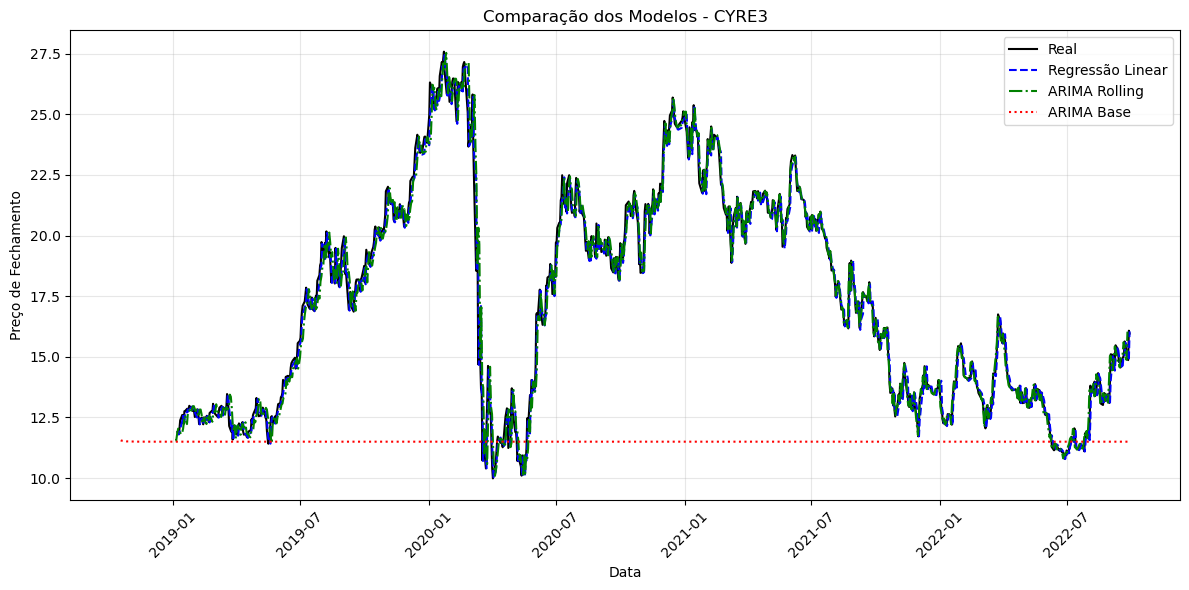

2025-06-18 22:39:17,670 - INFO - Carregando dados do CSV para a ação TEND3
2025-06-18 22:39:17,686 - INFO - Normalizando dados
2025-06-18 22:39:17,689 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:39:17,690 - INFO - Desnormalizando previsões
2025-06-18 22:39:17,691 - INFO - Avaliando modelo
2025-06-18 22:39:17,696 - INFO - 
Métricas de Treino:
2025-06-18 22:39:17,696 - INFO - MSE: 0.0038
2025-06-18 22:39:17,697 - INFO - RMSE: 0.0614
2025-06-18 22:39:17,698 - INFO - MAE: 0.0112
2025-06-18 22:39:17,698 - INFO - R2: 0.9937
2025-06-18 22:39:17,699 - INFO - 
Métricas de Validação:
2025-06-18 22:39:17,699 - INFO - MSE: 0.0579
2025-06-18 22:39:17,700 - INFO - RMSE: 0.2406
2025-06-18 22:39:17,701 - INFO - MAE: 0.1790
2025-06-18 22:39:17,701 - INFO - R2: 0.9641
2025-06-18 22:39:17,702 - INFO - 
Métricas de Teste:
2025-06-18 22:39:17,702 - INFO - MSE: 0.4892
2025-06-18 22:39:17,703 - INFO - RMSE: 0.6995
2025-06-18 22:39:17,704 - INFO - MAE: 0.4801
2025-06-18 22:39:17,704 - INFO


Processando: TEND3


2025-06-18 22:42:10,739 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:42:10,740 - INFO - MSE: 0.4434
2025-06-18 22:42:10,741 - INFO - RMSE: 0.6659
2025-06-18 22:42:10,741 - INFO - MAE: 0.4468
2025-06-18 22:42:10,742 - INFO - R2: 0.9932
2025-06-18 22:42:10,785 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:42:10,788 - INFO - Carregando dados para TEND3
2025-06-18 22:42:10,829 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para TEND3:
MSE: 0.4434
RMSE: 0.6659
MAE: 0.4468
R2: 0.9932


2025-06-18 22:42:11,122 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:42:11,123 - INFO - MSE: 97.0561
2025-06-18 22:42:11,124 - INFO - RMSE: 9.8517
2025-06-18 22:42:11,125 - INFO - MAE: 8.4692
2025-06-18 22:42:11,125 - INFO - R2: -0.4970
2025-06-18 22:42:11,171 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


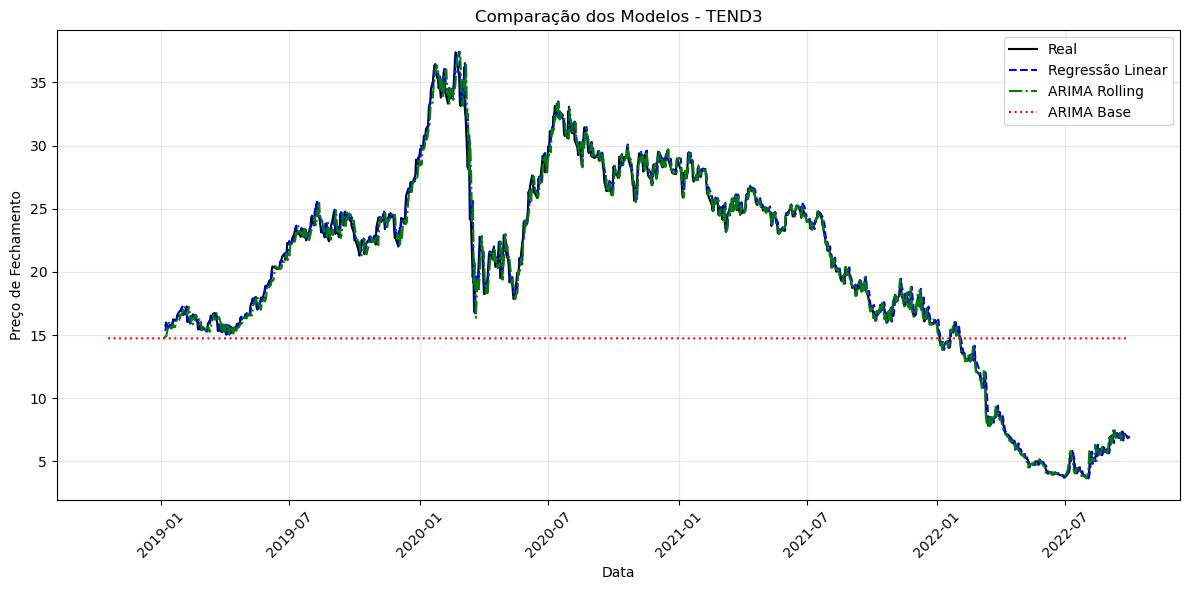

2025-06-18 22:42:11,381 - INFO - Carregando dados do CSV para a ação DIRR3
2025-06-18 22:42:11,399 - INFO - Normalizando dados
2025-06-18 22:42:11,402 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:42:11,403 - INFO - Desnormalizando previsões
2025-06-18 22:42:11,404 - INFO - Avaliando modelo
2025-06-18 22:42:11,409 - INFO - 
Métricas de Treino:
2025-06-18 22:42:11,410 - INFO - MSE: 0.0102
2025-06-18 22:42:11,411 - INFO - RMSE: 0.1008
2025-06-18 22:42:11,411 - INFO - MAE: 0.0733
2025-06-18 22:42:11,412 - INFO - R2: 0.9947
2025-06-18 22:42:11,413 - INFO - 
Métricas de Validação:
2025-06-18 22:42:11,414 - INFO - MSE: 0.0060
2025-06-18 22:42:11,415 - INFO - RMSE: 0.0772
2025-06-18 22:42:11,415 - INFO - MAE: 0.0597
2025-06-18 22:42:11,416 - INFO - R2: 0.9726
2025-06-18 22:42:11,416 - INFO - 
Métricas de Teste:
2025-06-18 22:42:11,417 - INFO - MSE: 0.0795
2025-06-18 22:42:11,418 - INFO - RMSE: 0.2820
2025-06-18 22:42:11,419 - INFO - MAE: 0.2098
2025-06-18 22:42:11,419 - INFO


Processando: DIRR3


2025-06-18 22:45:02,536 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:45:02,537 - INFO - MSE: 0.0755
2025-06-18 22:45:02,538 - INFO - RMSE: 0.2748
2025-06-18 22:45:02,538 - INFO - MAE: 0.1997
2025-06-18 22:45:02,538 - INFO - R2: 0.9766
2025-06-18 22:45:02,583 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:45:02,587 - INFO - Carregando dados para DIRR3
2025-06-18 22:45:02,628 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para DIRR3:
MSE: 0.0755
RMSE: 0.2748
MAE: 0.1997
R2: 0.9766


2025-06-18 22:45:02,956 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:45:02,956 - INFO - MSE: 20.4379
2025-06-18 22:45:02,957 - INFO - RMSE: 4.5208
2025-06-18 22:45:02,957 - INFO - MAE: 4.1489
2025-06-18 22:45:02,958 - INFO - R2: -5.3386
2025-06-18 22:45:02,992 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


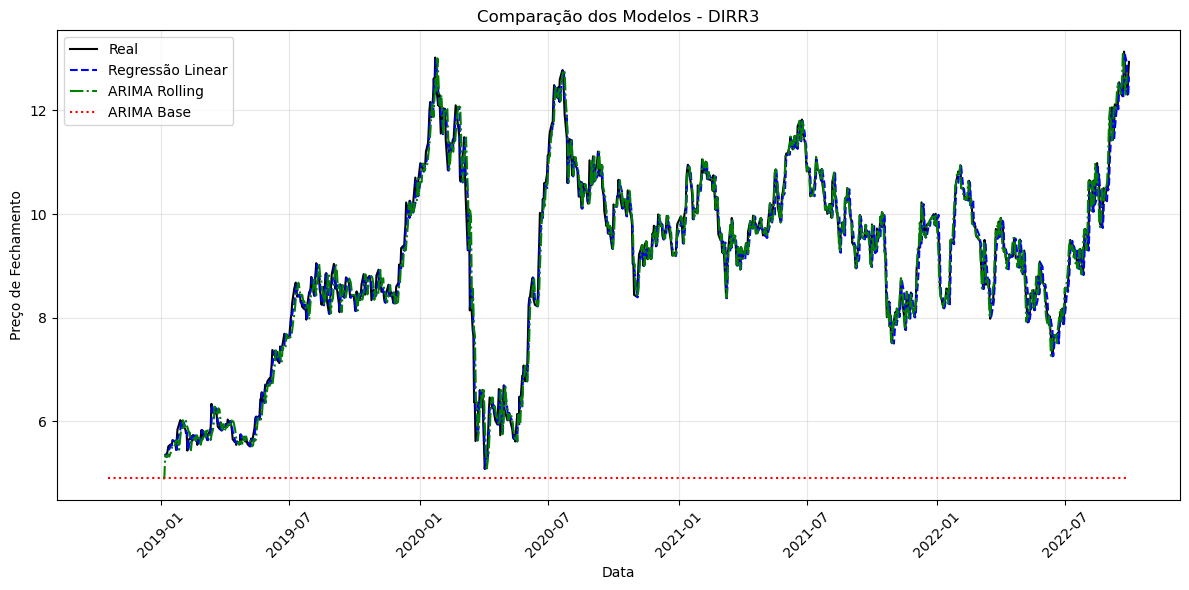

2025-06-18 22:45:03,207 - INFO - Carregando dados do CSV para a ação ELET3
2025-06-18 22:45:03,223 - INFO - Normalizando dados
2025-06-18 22:45:03,225 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:45:03,226 - INFO - Desnormalizando previsões
2025-06-18 22:45:03,227 - INFO - Avaliando modelo
2025-06-18 22:45:03,232 - INFO - 
Métricas de Treino:
2025-06-18 22:45:03,233 - INFO - MSE: 0.1000
2025-06-18 22:45:03,234 - INFO - RMSE: 0.3162
2025-06-18 22:45:03,234 - INFO - MAE: 0.1807
2025-06-18 22:45:03,235 - INFO - R2: 0.9958
2025-06-18 22:45:03,235 - INFO - 
Métricas de Validação:
2025-06-18 22:45:03,236 - INFO - MSE: 0.3826
2025-06-18 22:45:03,237 - INFO - RMSE: 0.6185
2025-06-18 22:45:03,237 - INFO - MAE: 0.4641
2025-06-18 22:45:03,238 - INFO - R2: 0.9596
2025-06-18 22:45:03,239 - INFO - 
Métricas de Teste:
2025-06-18 22:45:03,239 - INFO - MSE: 0.8560
2025-06-18 22:45:03,240 - INFO - RMSE: 0.9252
2025-06-18 22:45:03,240 - INFO - MAE: 0.6730
2025-06-18 22:45:03,240 - INFO


Processando: ELET3


2025-06-18 22:47:57,378 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:47:57,378 - INFO - MSE: 0.8350
2025-06-18 22:47:57,379 - INFO - RMSE: 0.9138
2025-06-18 22:47:57,380 - INFO - MAE: 0.6387
2025-06-18 22:47:57,380 - INFO - R2: 0.9773
2025-06-18 22:47:57,438 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:47:57,446 - INFO - Carregando dados para ELET3
2025-06-18 22:47:57,489 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para ELET3:
MSE: 0.8350
RMSE: 0.9138
MAE: 0.6387
R2: 0.9773


2025-06-18 22:47:57,712 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:47:57,713 - INFO - MSE: 193.4558
2025-06-18 22:47:57,714 - INFO - RMSE: 13.9088
2025-06-18 22:47:57,715 - INFO - MAE: 12.6314
2025-06-18 22:47:57,715 - INFO - R2: -4.2576
2025-06-18 22:47:57,759 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


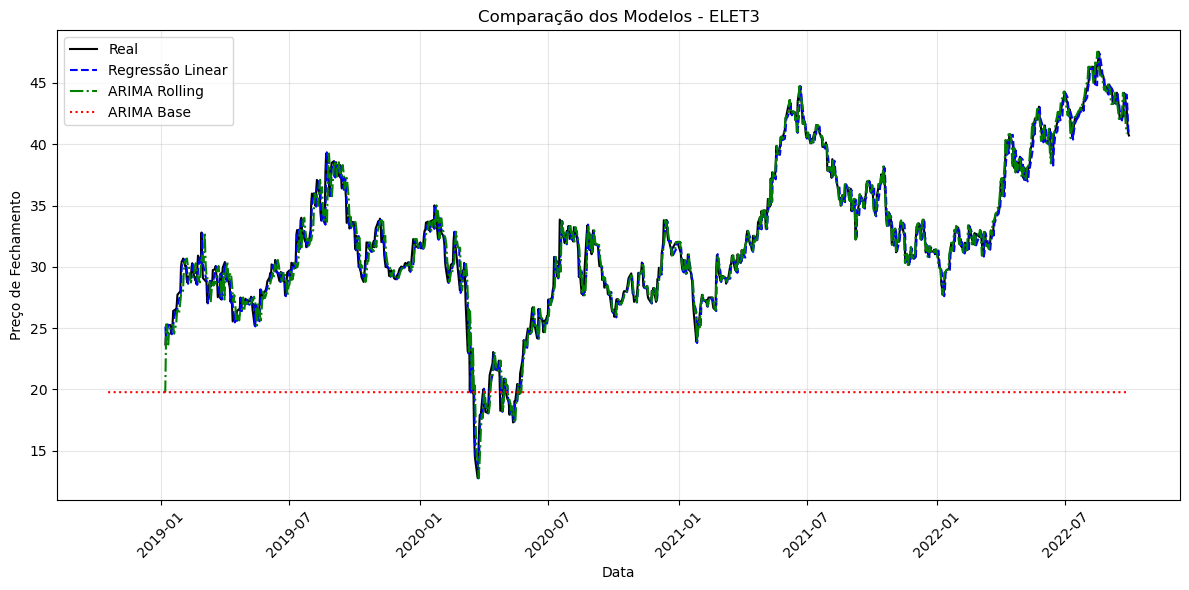

2025-06-18 22:47:57,977 - INFO - Carregando dados do CSV para a ação EQTL3
2025-06-18 22:47:57,998 - INFO - Normalizando dados
2025-06-18 22:47:58,000 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:47:58,001 - INFO - Desnormalizando previsões
2025-06-18 22:47:58,002 - INFO - Avaliando modelo
2025-06-18 22:47:58,007 - INFO - 
Métricas de Treino:
2025-06-18 22:47:58,007 - INFO - MSE: 0.0069
2025-06-18 22:47:58,008 - INFO - RMSE: 0.0832
2025-06-18 22:47:58,009 - INFO - MAE: 0.0535
2025-06-18 22:47:58,009 - INFO - R2: 0.9992
2025-06-18 22:47:58,010 - INFO - 
Métricas de Validação:
2025-06-18 22:47:58,010 - INFO - MSE: 0.0293
2025-06-18 22:47:58,011 - INFO - RMSE: 0.1711
2025-06-18 22:47:58,011 - INFO - MAE: 0.1397
2025-06-18 22:47:58,013 - INFO - R2: 0.9693
2025-06-18 22:47:58,013 - INFO - 
Métricas de Teste:
2025-06-18 22:47:58,013 - INFO - MSE: 0.1571
2025-06-18 22:47:58,014 - INFO - RMSE: 0.3963
2025-06-18 22:47:58,014 - INFO - MAE: 0.2884
2025-06-18 22:47:58,015 - INFO


Processando: EQTL3


2025-06-18 22:50:52,524 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:50:52,525 - INFO - MSE: 0.1489
2025-06-18 22:50:52,526 - INFO - RMSE: 0.3859
2025-06-18 22:50:52,526 - INFO - MAE: 0.2748
2025-06-18 22:50:52,527 - INFO - R2: 0.9853
2025-06-18 22:50:52,574 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:50:52,578 - INFO - Carregando dados para EQTL3
2025-06-18 22:50:52,624 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para EQTL3:
MSE: 0.1489
RMSE: 0.3859
MAE: 0.2748
R2: 0.9853


2025-06-18 22:50:52,936 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:50:52,936 - INFO - MSE: 59.8145
2025-06-18 22:50:52,937 - INFO - RMSE: 7.7340
2025-06-18 22:50:52,937 - INFO - MAE: 7.0510
2025-06-18 22:50:52,938 - INFO - R2: -4.9238
2025-06-18 22:50:52,978 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


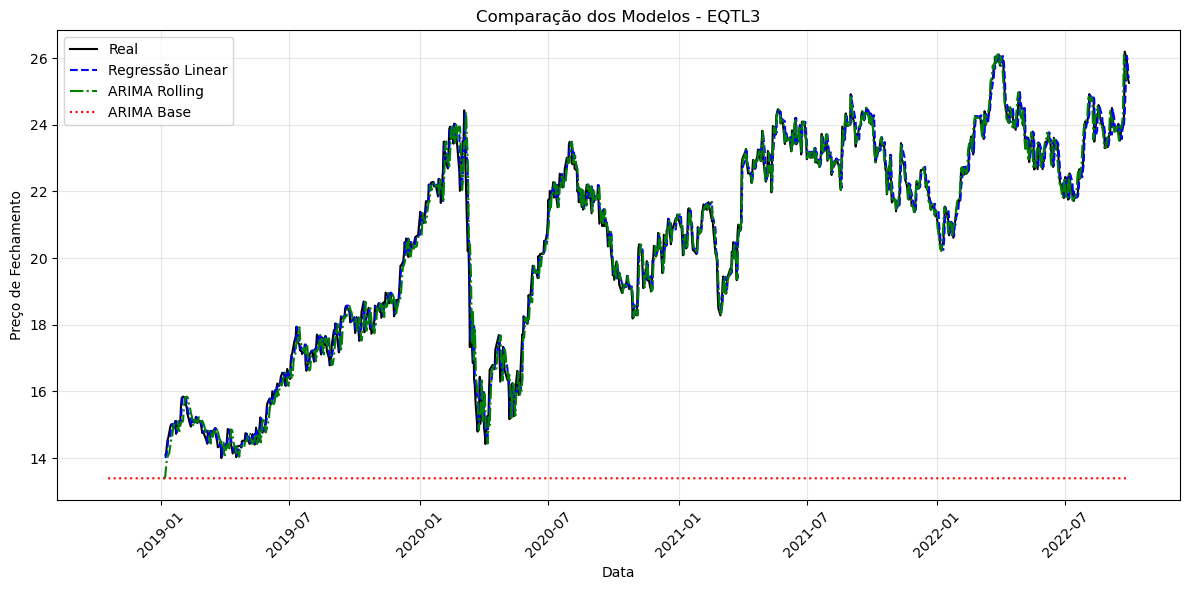

2025-06-18 22:50:53,199 - INFO - Carregando dados do CSV para a ação CMIG4
2025-06-18 22:50:53,215 - INFO - Normalizando dados
2025-06-18 22:50:53,218 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:50:53,219 - INFO - Desnormalizando previsões
2025-06-18 22:50:53,220 - INFO - Avaliando modelo
2025-06-18 22:50:53,224 - INFO - 
Métricas de Treino:
2025-06-18 22:50:53,225 - INFO - MSE: 0.0034
2025-06-18 22:50:53,226 - INFO - RMSE: 0.0584
2025-06-18 22:50:53,226 - INFO - MAE: 0.0404
2025-06-18 22:50:53,227 - INFO - R2: 0.9902
2025-06-18 22:50:53,227 - INFO - 
Métricas de Validação:
2025-06-18 22:50:53,229 - INFO - MSE: 0.0041
2025-06-18 22:50:53,229 - INFO - RMSE: 0.0639
2025-06-18 22:50:53,230 - INFO - MAE: 0.0450
2025-06-18 22:50:53,230 - INFO - R2: 0.9848
2025-06-18 22:50:53,231 - INFO - 
Métricas de Teste:
2025-06-18 22:50:53,231 - INFO - MSE: 0.0093
2025-06-18 22:50:53,232 - INFO - RMSE: 0.0966
2025-06-18 22:50:53,232 - INFO - MAE: 0.0707
2025-06-18 22:50:53,233 - INFO


Processando: CMIG4


2025-06-18 22:53:46,806 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:53:46,807 - INFO - MSE: 0.0088
2025-06-18 22:53:46,808 - INFO - RMSE: 0.0935
2025-06-18 22:53:46,809 - INFO - MAE: 0.0667
2025-06-18 22:53:46,809 - INFO - R2: 0.9913
2025-06-18 22:53:46,860 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:53:46,864 - INFO - Carregando dados para CMIG4
2025-06-18 22:53:46,913 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para CMIG4:
MSE: 0.0088
RMSE: 0.0935
MAE: 0.0667
R2: 0.9913


2025-06-18 22:53:47,261 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:53:47,262 - INFO - MSE: 1.3379
2025-06-18 22:53:47,264 - INFO - RMSE: 1.1567
2025-06-18 22:53:47,264 - INFO - MAE: 0.8470
2025-06-18 22:53:47,265 - INFO - R2: -0.3323
2025-06-18 22:53:47,310 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


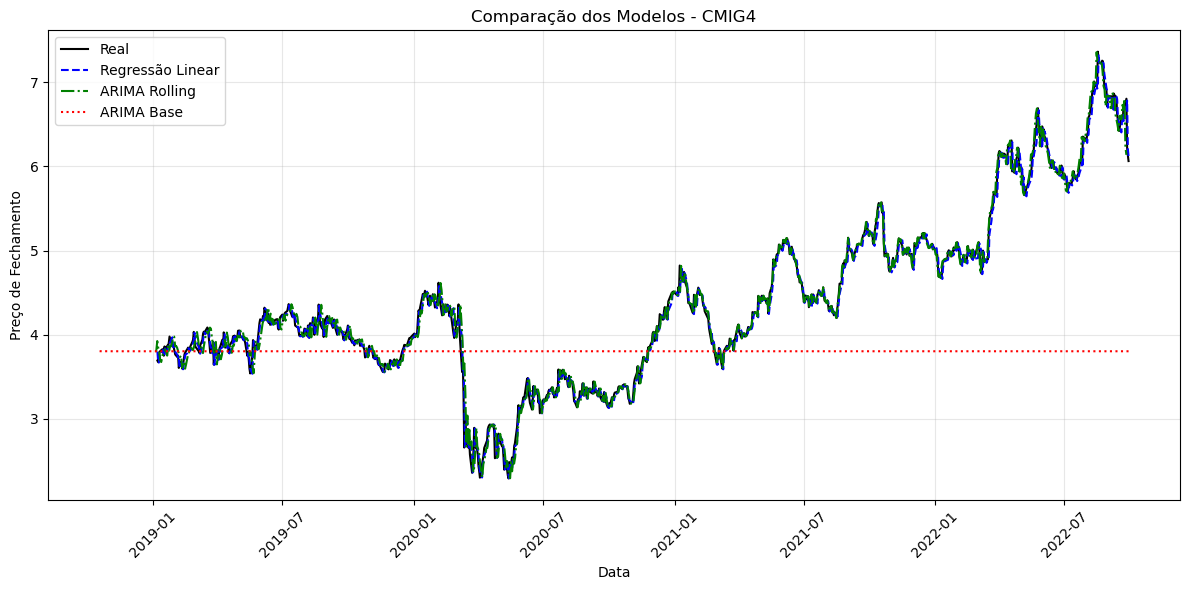

2025-06-18 22:53:47,564 - INFO - Carregando dados do CSV para a ação PETR3
2025-06-18 22:53:47,585 - INFO - Normalizando dados
2025-06-18 22:53:47,588 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:53:47,592 - INFO - Desnormalizando previsões
2025-06-18 22:53:47,594 - INFO - Avaliando modelo
2025-06-18 22:53:47,600 - INFO - 
Métricas de Treino:
2025-06-18 22:53:47,601 - INFO - MSE: 0.0198
2025-06-18 22:53:47,602 - INFO - RMSE: 0.1408
2025-06-18 22:53:47,603 - INFO - MAE: 0.1054
2025-06-18 22:53:47,604 - INFO - R2: 0.9954
2025-06-18 22:53:47,604 - INFO - 
Métricas de Validação:
2025-06-18 22:53:47,605 - INFO - MSE: 0.0547
2025-06-18 22:53:47,605 - INFO - RMSE: 0.2339
2025-06-18 22:53:47,607 - INFO - MAE: 0.1607
2025-06-18 22:53:47,608 - INFO - R2: 0.9542
2025-06-18 22:53:47,609 - INFO - 
Métricas de Teste:
2025-06-18 22:53:47,609 - INFO - MSE: 0.0802
2025-06-18 22:53:47,610 - INFO - RMSE: 0.2832
2025-06-18 22:53:47,610 - INFO - MAE: 0.1916
2025-06-18 22:53:47,611 - INFO


Processando: PETR3


2025-06-18 22:56:40,312 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:56:40,312 - INFO - MSE: 0.0751
2025-06-18 22:56:40,313 - INFO - RMSE: 0.2741
2025-06-18 22:56:40,313 - INFO - MAE: 0.1797
2025-06-18 22:56:40,314 - INFO - R2: 0.9933
2025-06-18 22:56:40,369 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:56:40,374 - INFO - Carregando dados para PETR3
2025-06-18 22:56:40,424 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para PETR3:
MSE: 0.0751
RMSE: 0.2741
MAE: 0.1797
R2: 0.9933


2025-06-18 22:56:40,803 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:56:40,804 - INFO - MSE: 16.0281
2025-06-18 22:56:40,804 - INFO - RMSE: 4.0035
2025-06-18 22:56:40,805 - INFO - MAE: 2.7966
2025-06-18 22:56:40,805 - INFO - R2: -0.4271
2025-06-18 22:56:40,844 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


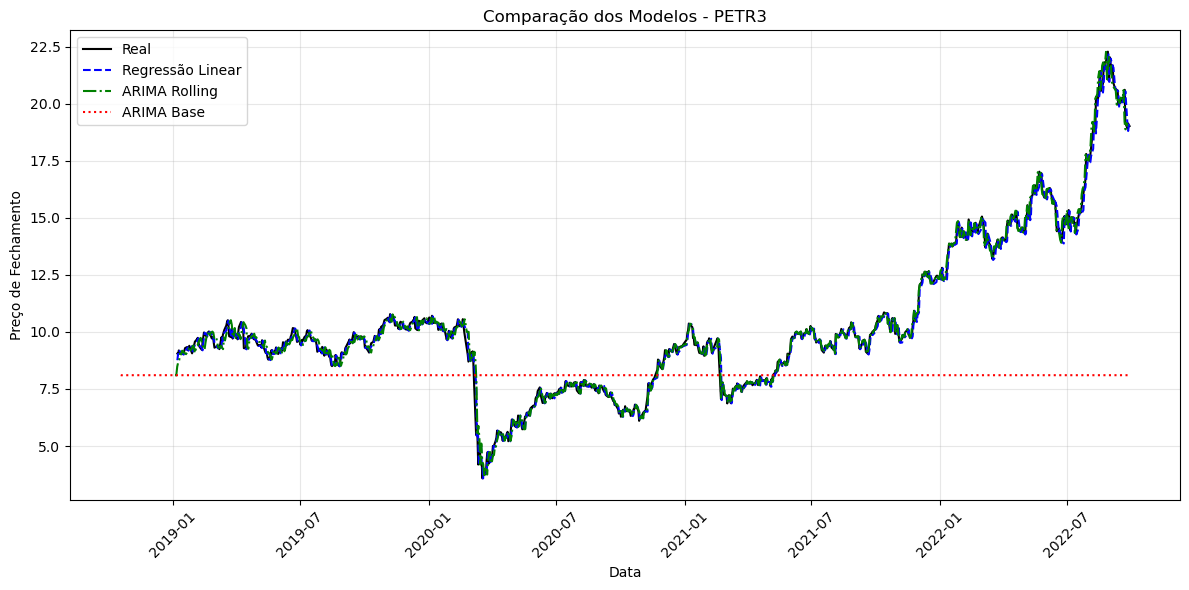

2025-06-18 22:56:41,059 - INFO - Carregando dados do CSV para a ação VALE3
2025-06-18 22:56:41,077 - INFO - Normalizando dados
2025-06-18 22:56:41,079 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:56:41,080 - INFO - Desnormalizando previsões
2025-06-18 22:56:41,081 - INFO - Avaliando modelo
2025-06-18 22:56:41,087 - INFO - 
Métricas de Treino:
2025-06-18 22:56:41,087 - INFO - MSE: 0.1510
2025-06-18 22:56:41,088 - INFO - RMSE: 0.3886
2025-06-18 22:56:41,088 - INFO - MAE: 0.2947
2025-06-18 22:56:41,089 - INFO - R2: 0.9945
2025-06-18 22:56:41,089 - INFO - 
Métricas de Validação:
2025-06-18 22:56:41,090 - INFO - MSE: 0.4229
2025-06-18 22:56:41,091 - INFO - RMSE: 0.6503
2025-06-18 22:56:41,091 - INFO - MAE: 0.5032
2025-06-18 22:56:41,092 - INFO - R2: 0.9682
2025-06-18 22:56:41,093 - INFO - 
Métricas de Teste:
2025-06-18 22:56:41,093 - INFO - MSE: 1.5617
2025-06-18 22:56:41,094 - INFO - RMSE: 1.2497
2025-06-18 22:56:41,094 - INFO - MAE: 0.8785
2025-06-18 22:56:41,095 - INFO


Processando: VALE3


2025-06-18 22:59:32,167 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:59:32,168 - INFO - MSE: 1.4774
2025-06-18 22:59:32,168 - INFO - RMSE: 1.2155
2025-06-18 22:59:32,169 - INFO - MAE: 0.8357
2025-06-18 22:59:32,169 - INFO - R2: 0.9955
2025-06-18 22:59:32,211 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 22:59:32,215 - INFO - Carregando dados para VALE3
2025-06-18 22:59:32,257 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para VALE3:
MSE: 1.4774
RMSE: 1.2155
MAE: 0.8357
R2: 0.9955


2025-06-18 22:59:32,555 - INFO - 
Métricas no conjunto de teste:
2025-06-18 22:59:32,556 - INFO - MSE: 640.8722
2025-06-18 22:59:32,556 - INFO - RMSE: 25.3155
2025-06-18 22:59:32,557 - INFO - MAE: 18.8716
2025-06-18 22:59:32,558 - INFO - R2: -0.9444
2025-06-18 22:59:32,590 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


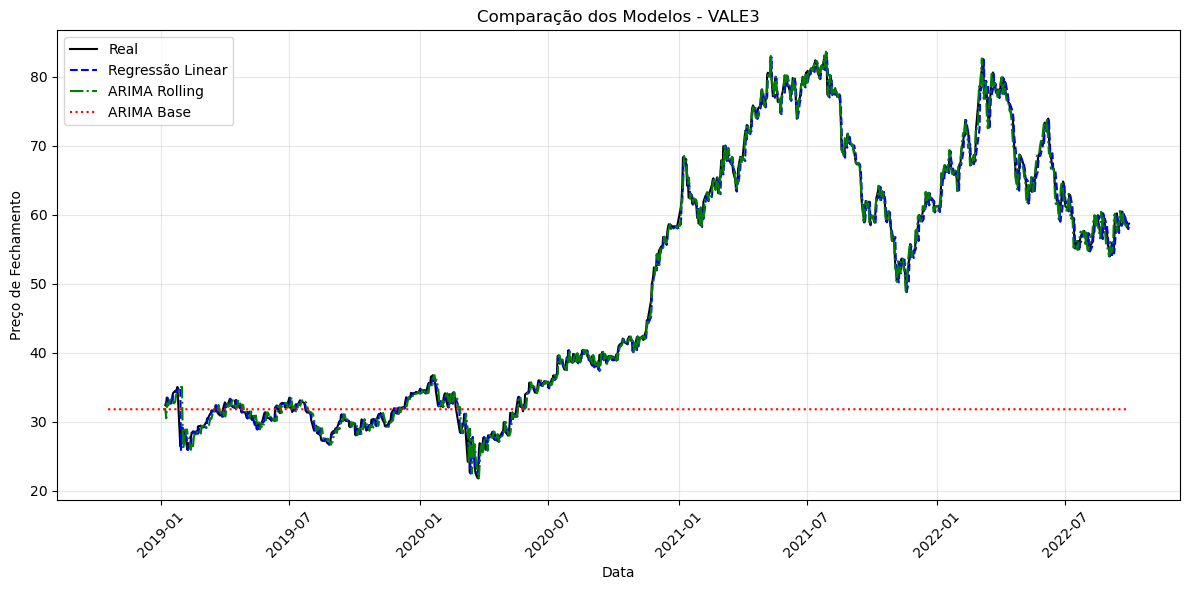

2025-06-18 22:59:32,809 - INFO - Carregando dados do CSV para a ação BRAP3
2025-06-18 22:59:32,830 - INFO - Normalizando dados
2025-06-18 22:59:32,835 - INFO - Treinando modelo usando a equação normal
2025-06-18 22:59:32,837 - INFO - Desnormalizando previsões
2025-06-18 22:59:32,838 - INFO - Avaliando modelo
2025-06-18 22:59:32,844 - INFO - 
Métricas de Treino:
2025-06-18 22:59:32,844 - INFO - MSE: 0.0042
2025-06-18 22:59:32,845 - INFO - RMSE: 0.0644
2025-06-18 22:59:32,846 - INFO - MAE: 0.0461
2025-06-18 22:59:32,846 - INFO - R2: 0.9964
2025-06-18 22:59:32,847 - INFO - 
Métricas de Validação:
2025-06-18 22:59:32,848 - INFO - MSE: 0.0174
2025-06-18 22:59:32,848 - INFO - RMSE: 0.1321
2025-06-18 22:59:32,848 - INFO - MAE: 0.0962
2025-06-18 22:59:32,849 - INFO - R2: 0.8955
2025-06-18 22:59:32,850 - INFO - 
Métricas de Teste:
2025-06-18 22:59:32,850 - INFO - MSE: 0.0829
2025-06-18 22:59:32,851 - INFO - RMSE: 0.2879
2025-06-18 22:59:32,852 - INFO - MAE: 0.2001
2025-06-18 22:59:32,852 - INFO


Processando: BRAP3


2025-06-18 23:02:25,318 - INFO - 
Métricas no conjunto de teste:
2025-06-18 23:02:25,319 - INFO - MSE: 0.0787
2025-06-18 23:02:25,319 - INFO - RMSE: 0.2805
2025-06-18 23:02:25,320 - INFO - MAE: 0.1910
2025-06-18 23:02:25,320 - INFO - R2: 0.9968
2025-06-18 23:02:25,364 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-18 23:02:25,368 - INFO - Carregando dados para BRAP3
2025-06-18 23:02:25,410 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para BRAP3:
MSE: 0.0787
RMSE: 0.2805
MAE: 0.1910
R2: 0.9968


2025-06-18 23:02:25,788 - INFO - 
Métricas no conjunto de teste:
2025-06-18 23:02:25,788 - INFO - MSE: 55.3191
2025-06-18 23:02:25,789 - INFO - RMSE: 7.4377
2025-06-18 23:02:25,789 - INFO - MAE: 5.6334
2025-06-18 23:02:25,790 - INFO - R2: -1.2661
2025-06-18 23:02:25,823 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


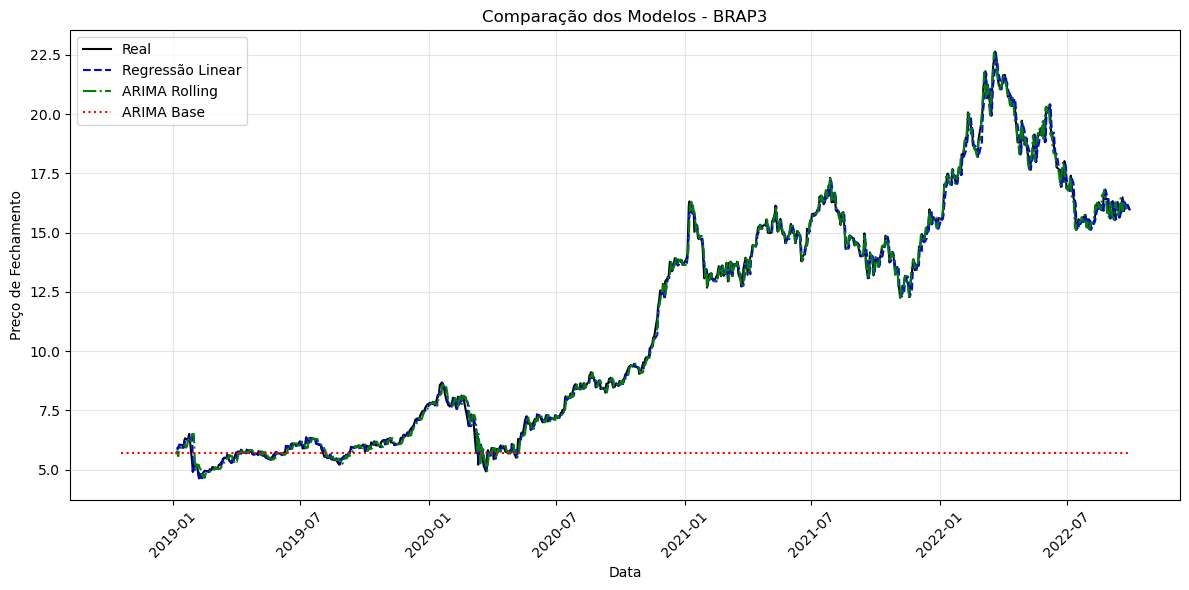

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from main.classes.neural_networks.training.train_linear_regression import train_and_evaluate as train_lr
from main.classes.neural_networks.training.train_arima import train_and_evaluate_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Lista de ações analisadas
acoes = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3' ,'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']

# Configurações
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir_lr = "../../saved_models/regressao"
model_dir_arima = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
window = 3

# Carrega DataFrame completo
df = pd.read_csv(csv_path, parse_dates=["Date"])
df.set_index("Date", inplace=True)
df = df.sort_index()

for acao in acoes:
    print(f"\nProcessando: {acao}")
    serie = df[acao].dropna()

    # ---------- Regressão Linear ----------
    _, _, _, _, _, y_test_lr, y_pred_lr = train_lr(csv_path, acao, window, model_dir_lr, version)

    start_idx_lr = df.index.get_indexer([pd.to_datetime(split_date)], method='bfill')[0] + window
    dates_lr = df.index[start_idx_lr : start_idx_lr + len(y_pred_lr)]
    y_test_recalculated_lr = serie.loc[dates_lr]
       # ---------- ARIMA Rolling ----------
    rolling = True
    try:
        arima_model, metrics, predictions = train_and_evaluate_arima(
            csv_path, acao, order, model_dir, version, split_date, rolling, step_size
        )
        
        print(f"\nMétricas do modelo ARIMA para {acao}:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    except Exception as e:
        print(f"Erro durante o treinamento: {e}")
    # Alinhamento correto: previsões no final da série (rolling)
    y_pred_arima_rolling = predictions
    serie_completa = df[acao].dropna()
    # Redefine a escala de tempo do ARIMA Rolling para caber no mesmo intervalo da Regressão Linear
    dates_arima_rolling = pd.date_range(
        start=dates_lr[0],
        end=dates_lr[-1],
        periods=len(y_pred_arima_rolling)
    )
    # Desloca 1 dia para a esquerda
    dates_arima_rolling -= pd.Timedelta(days=3)

    y_true_arima_rolling = serie_completa.iloc[-len(y_pred_arima_rolling):]
    # Alinhar previsões com as datas corretas
    #start_idx = df.index.get_indexer([pd.to_datetime(split_date)], method='bfill')[0]
    #test_dates = df.index[start_idx : start_idx + len(predictions)]
    #test_values = df[target].iloc[start_idx : start_idx + len(predictions)]
    # ---------- ARIMA Base ----------
    rolling = False
    _, _, y_pred_arima_base = train_and_evaluate_arima(
        csv_path, acao, order, model_dir_arima, version,
        split_date, rolling, step_size
    )
        # Alinha o ARIMA Base com o final da série, assim como o Rolling
    dates_arima_base = serie.index[-len(y_pred_arima_base):]
    y_test_recalculated_base = serie.loc[dates_arima_base]


    # ---------- Plot (ajustado) ----------
    plt.figure(figsize=(12, 6))

    # Plot da série real da regressão linear
    plt.plot(dates_lr, y_test_recalculated_lr, label="Real", color="black")
    plt.plot(dates_lr, y_pred_lr, label="Regressão Linear", linestyle="--", color="blue")

    # Plot da série real e previsão do ARIMA Rolling
    plt.plot(dates_arima_rolling, y_pred_arima_rolling, label="ARIMA Rolling", linestyle="-.", color="green")

    # Plot do ARIMA Base
    plt.plot(dates_arima_base, y_pred_arima_base, label="ARIMA Base", linestyle=":", color="red")

    plt.title(f"Comparação dos Modelos - {acao}")
    plt.xlabel("Data")
    plt.ylabel("Preço de Fechamento")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Comparação do Residuo absoluto

2025-06-25 13:24:33,162 - INFO - Carregando dados do CSV para a ação ITUB4
2025-06-25 13:24:33,182 - INFO - Normalizando dados
2025-06-25 13:24:33,187 - INFO - Treinando modelo usando a equação normal
2025-06-25 13:24:33,189 - INFO - Desnormalizando previsões
2025-06-25 13:24:33,191 - INFO - Avaliando modelo
2025-06-25 13:24:33,198 - INFO - 
Métricas de Treino:
2025-06-25 13:24:33,199 - INFO - MSE: 0.0539
2025-06-25 13:24:33,200 - INFO - RMSE: 0.2322
2025-06-25 13:24:33,201 - INFO - MAE: 0.1657
2025-06-25 13:24:33,202 - INFO - R2: 0.9960
2025-06-25 13:24:33,202 - INFO - 
Métricas de Validação:
2025-06-25 13:24:33,203 - INFO - MSE: 0.2061
2025-06-25 13:24:33,203 - INFO - RMSE: 0.4540
2025-06-25 13:24:33,204 - INFO - MAE: 0.3501
2025-06-25 13:24:33,205 - INFO - R2: 0.9564
2025-06-25 13:24:33,206 - INFO - 
Métricas de Teste:
2025-06-25 13:24:33,206 - INFO - MSE: 0.2499
2025-06-25 13:24:33,207 - INFO - RMSE: 0.4999
2025-06-25 13:24:33,208 - INFO - MAE: 0.3664
2025-06-25 13:24:33,208 - INFO

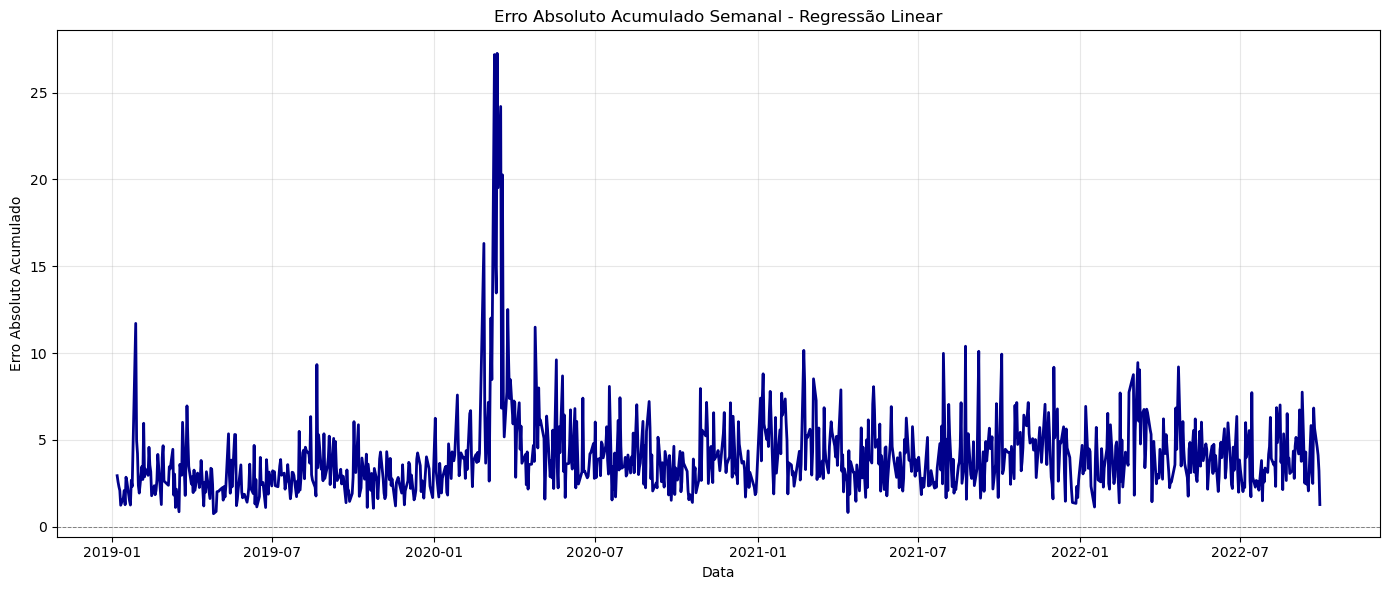

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Adiciona o caminho do projeto
sys.path.append(os.path.abspath("../../"))

# Importa as funções
from classes.neural_networks.training.train_linear_regression import train_and_evaluate, load_data

# Define os parâmetros
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
window = 3
model_dir = "../../saved_models/regressao"
version = "v1.0"
acoes = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3', 'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']

# Carrega os dados
df = load_data(csv_path)
df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

# Dicionários para armazenar resíduos
residuos_dict = {}

# Processa cada ação

for acao in acoes:
    model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(
        csv_path, acao, window, model_dir, version)

    # Calcula resíduo absoluto
    res = np.abs(y_test - test_predictions)

    # Datas correspondentes do final da série (convertidas para datetime)
    dates = pd.to_datetime(df[df[acao].notna()].index[-len(y_test):])

    # Cria Series com índice datetime
    res_series = pd.Series(res, index=dates)

    # Reamostragem semanal
    residuos_dict[acao] = res_series.resample('D').mean().interpolate()

# Combina tudo em um DataFrame
residuos_df = pd.DataFrame(residuos_dict)

# Soma absoluta dos resíduos em cada semana
erro_acumulado = residuos_df.sum(axis=1)

# Salva para uso futuro
erro_acumulado.to_csv("erro_acumulado_lr.csv")

# Plota o gráfico
plt.figure(figsize=(14, 6))
plt.plot(erro_acumulado.index, erro_acumulado, color='darkblue', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.7)
plt.title("Erro Absoluto Acumulado Diário - Regressão Linear")
plt.xlabel("Data")
plt.ylabel("Erro Absoluto Acumulado")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2025-06-25 13:25:12,093 - INFO - Loading series for target ITUB4
2025-06-25 13:25:12,192 - INFO - Split sizes → train: 1978, val: 245, test: 931
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-pa

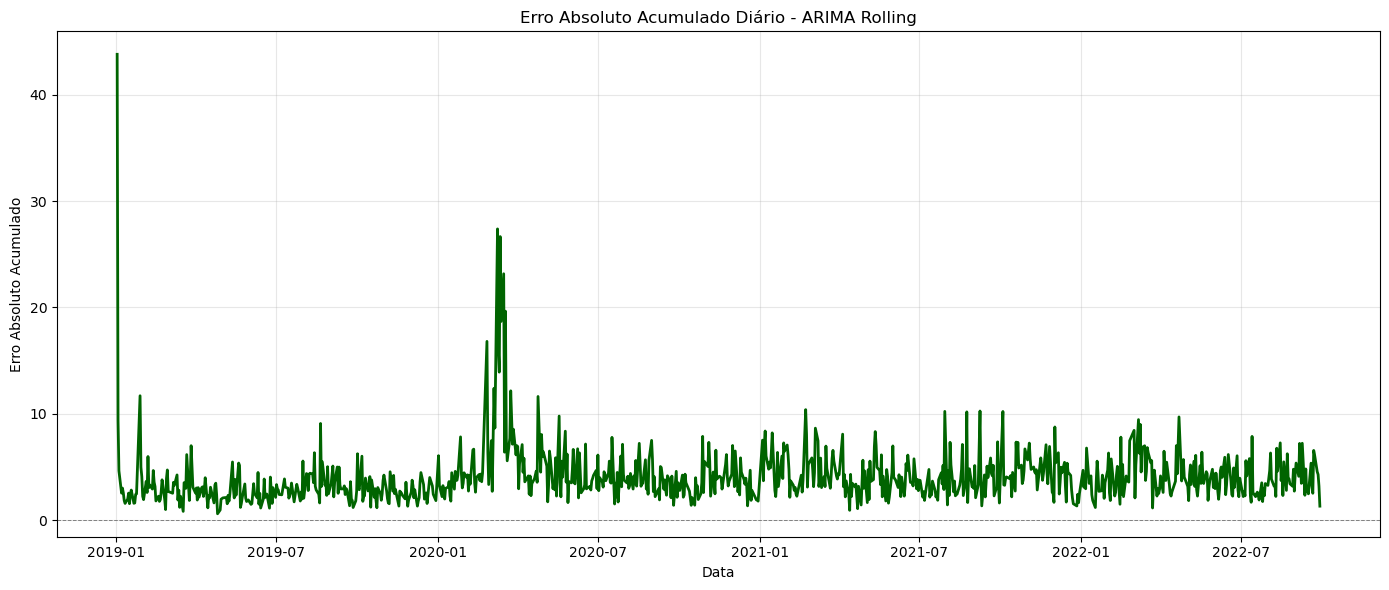

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

from main.classes.neural_networks.training.train_arima import (
    train_and_evaluate_arima,
    load_series,
    split_series
)

# Parâmetros
acoes = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3', 'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)
train_end = "2017-12-31"
val_end = "2018-12-31"
rolling = True
step_size = 1

# Dicionário para resíduos
residuos_arima = {}

# Processamento por ativo
for acao in acoes:
    try:
        ts = load_series(csv_path, acao)
        train, val, test = split_series(ts, train_end, val_end)

        result = train_and_evaluate_arima(
            csv_path=csv_path,
            target=acao,
            order=order,
            model_dir=model_dir,
            version=version,
            train_end=train_end,
            val_end=val_end,
            rolling=rolling,
            step_size=step_size
        )

        y_pred = result["predictions"]["test"]
        y_true = test.values

        # Verificação de alinhamento
        if len(y_true) != len(y_pred):
            print(f"[{acao}] Erro: y_true ({len(y_true)}) != y_pred ({len(y_pred)})")
            continue

        dates = test.index
        res = pd.Series(np.abs(y_true - y_pred), index=pd.to_datetime(dates))
        residuos_arima[acao] = res.resample("D").mean().interpolate()

    except Exception as e:
        print(f"Erro ao processar {acao}: {e}")

# DataFrame combinado e soma dos resíduos
df_residuos_arima = pd.DataFrame(residuos_arima)
erro_acumulado_arima = df_residuos_arima.sum(axis=1)

# Salva e plota
erro_acumulado_arima.to_csv("erro_acumulado_arima_rolling.csv")

plt.figure(figsize=(14, 6))
plt.plot(erro_acumulado_arima.index, erro_acumulado_arima, color='darkgreen', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.7)
plt.title("Erro Absoluto Acumulado Diário - ARIMA Rolling")
plt.xlabel("Data")
plt.ylabel("Erro Absoluto Acumulado")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2025-06-25 13:29:02,305 - INFO - Carregando dados para ITUB4
2025-06-25 13:29:02,344 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-25 13:29:02,884 - INFO - 
Métricas no conjunto de teste:
2025-06-25 13:29:02,885 - INFO - MSE: 24.1392
2025-06-25 13:29:02,886 - INFO - RMSE: 4.9132
2025-06-25 13:29:02,886 - INFO - MAE: 4.0273
2025-06-25 13:29:02,887 - INFO - R2: -0.9676
2025-06-25 13:29:02,923 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima

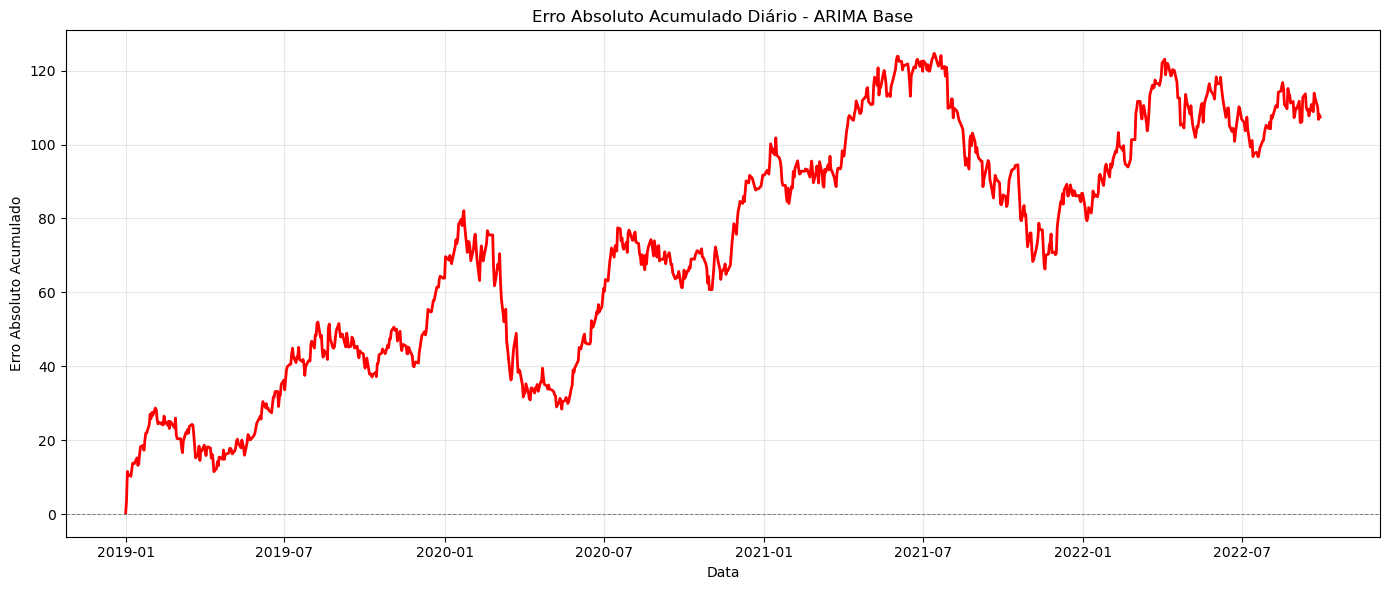

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from main.classes.neural_networks.training.train_arimaema import (
    train_and_evaluate_arima,
    load_data,
    split_data
)

# Parâmetros
acoes = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3', 'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)
split_date = "2019-01-01"
rolling = False  # ARIMA Base
step_size = 1

# Carrega os dados com frequência definida
df = load_data(csv_path)

residuos_arima = {}

for acao in acoes:
    try:
        train, test = split_data(df, acao, split_date)

        _, metrics, predictions = train_and_evaluate_arima(
            csv_path=csv_path,
            target=acao,
            order=order,
            model_dir=model_dir,
            version=version,
            split_date=split_date,
            rolling=rolling,
            step_size=step_size
        )

        y_pred = np.array(predictions)
        y_true = test.values

        if len(y_true) != len(y_pred):
            print(f"[{acao}] Erro: y_true ({len(y_true)}) != y_pred ({len(y_pred)})")
            continue

        # Índices para o cálculo do resíduo
        dates = test.index[:len(y_pred)]
        res = pd.Series(np.abs(y_true[:len(y_pred)] - y_pred), index=pd.to_datetime(dates))
        residuos_arima[acao] = res.resample("D").mean().interpolate()

    except Exception as e:
        print(f"Erro ao processar {acao}: {e}")

# DataFrame e soma dos resíduos
df_residuos_arima = pd.DataFrame(residuos_arima)
erro_acumulado_arima = df_residuos_arima.sum(axis=1)

# Salva e plota
erro_acumulado_arima.to_csv("erro_acumulado_arima_base.csv")

plt.figure(figsize=(14, 6))
plt.plot(erro_acumulado_arima.index, erro_acumulado_arima, color='red', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.7)
plt.title("Erro Absoluto Acumulado Diário - ARIMA Base")
plt.xlabel("Data")
plt.ylabel("Erro Absoluto Acumulado")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

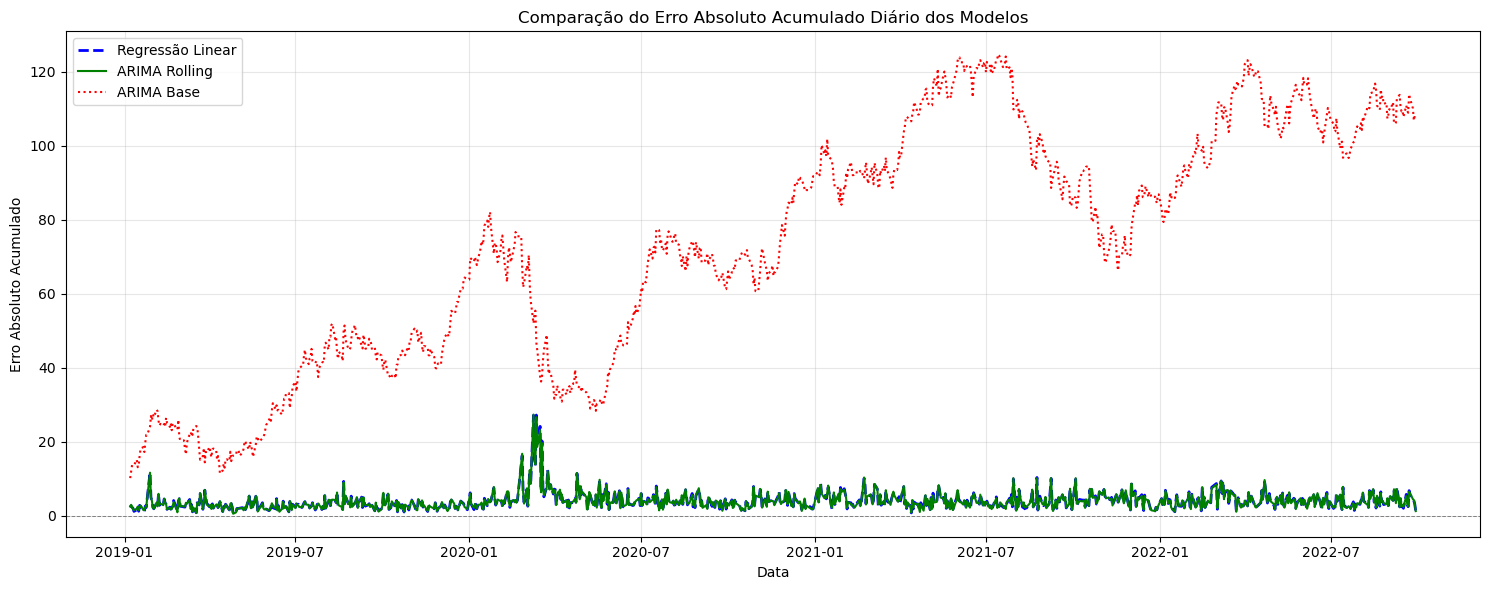

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Caminhos dos arquivos CSV salvos anteriormente
csv_lr = "erro_acumulado_lr.csv"
csv_arima_rolling = "erro_acumulado_arima_rolling.csv"
csv_arima_base = "erro_acumulado_arima_base.csv"

# Carrega os dados
erro_lr = pd.read_csv(csv_lr, index_col=0, parse_dates=True).squeeze()
erro_arima_rolling = pd.read_csv(csv_arima_rolling, index_col=0, parse_dates=True).squeeze()
erro_arima_base = pd.read_csv(csv_arima_base, index_col=0, parse_dates=True).squeeze()

# Junta os índices (caso haja pequenos desvios)
common_index = erro_lr.index.intersection(erro_arima_rolling.index).intersection(erro_arima_base.index)

# Alinha as séries no mesmo intervalo
erro_lr = erro_lr.loc[common_index]
erro_arima_rolling = erro_arima_rolling.loc[common_index]
erro_arima_base = erro_arima_base.loc[common_index]

# Plot único para comparação
plt.figure(figsize=(15, 6))
plt.plot(common_index, erro_lr, label="Regressão Linear", linestyle='--', color='blue', linewidth=2)
plt.plot(common_index, erro_arima_rolling, label="ARIMA Rolling", linestyle='-', color='green')
plt.plot(common_index, erro_arima_base, label="ARIMA Base", linestyle=':', color='red')

plt.title("Comparação do Erro Absoluto Acumulado Diário dos Modelos")
plt.xlabel("Data")
plt.ylabel("Erro Absoluto Acumulado")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.7)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

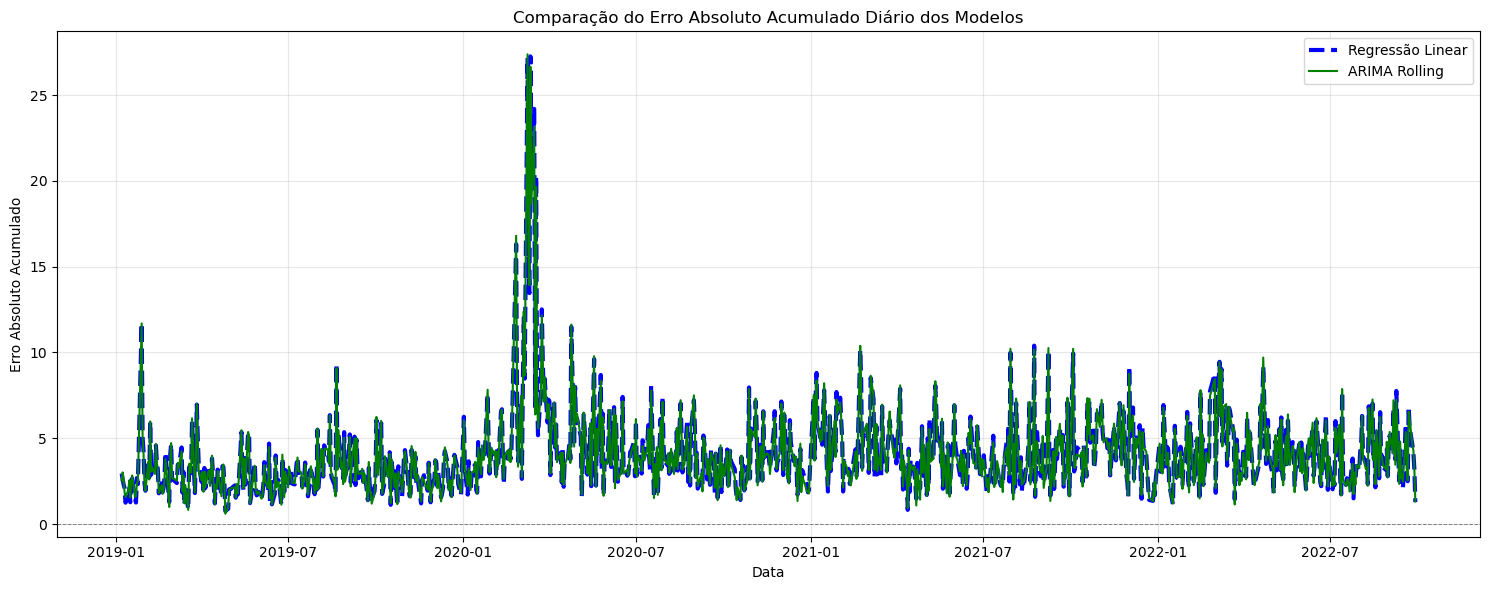

In [28]:
# Plot único para comparação
plt.figure(figsize=(15, 6))
plt.plot(common_index, erro_lr, label="Regressão Linear", linestyle='--', color='blue', linewidth=3)
plt.plot(common_index, erro_arima_rolling, label="ARIMA Rolling", linestyle='-', color='green')


plt.title("Comparação do Erro Absoluto Acumulado Diário dos Modelos")
plt.xlabel("Data")
plt.ylabel("Erro Absoluto Acumulado")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.7)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

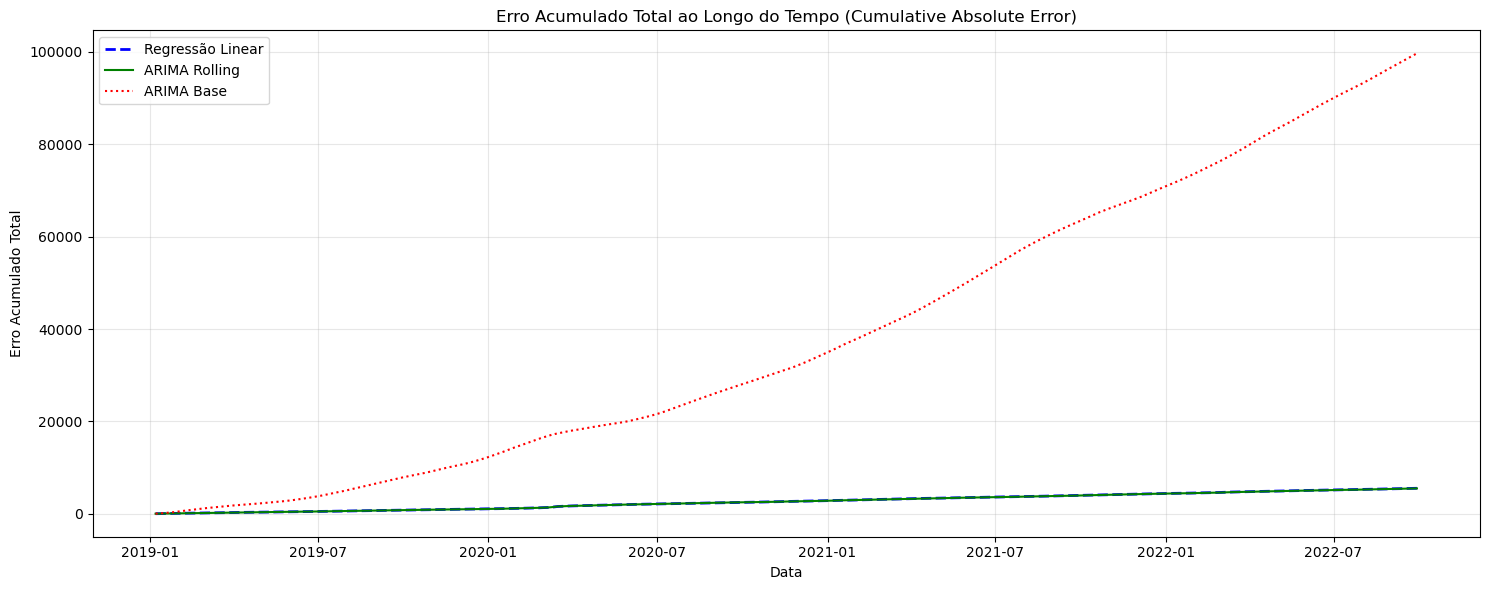

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Caminhos dos arquivos
csv_lr = "erro_acumulado_lr.csv"
csv_arima_rolling = "erro_acumulado_arima_rolling.csv"
csv_arima_base = "erro_acumulado_arima_base.csv"

# Carrega os dados
erro_lr = pd.read_csv(csv_lr, index_col=0, parse_dates=True).squeeze()
erro_arima_rolling = pd.read_csv(csv_arima_rolling, index_col=0, parse_dates=True).squeeze()
erro_arima_base = pd.read_csv(csv_arima_base, index_col=0, parse_dates=True).squeeze()

# Alinha os índices
common_index = erro_lr.index.intersection(erro_arima_rolling.index).intersection(erro_arima_base.index)
erro_lr = erro_lr.loc[common_index]
erro_arima_rolling = erro_arima_rolling.loc[common_index]
erro_arima_base = erro_arima_base.loc[common_index]

# Soma cumulativa (erro acumulado total ao longo do tempo)
erro_cum_lr = erro_lr.cumsum()
erro_cum_arima_rolling = erro_arima_rolling.cumsum()
erro_cum_arima_base = erro_arima_base.cumsum()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(common_index, erro_cum_lr, label="Regressão Linear", linestyle='--', color='blue', linewidth=2)
plt.plot(common_index, erro_cum_arima_rolling, label="ARIMA Rolling", linestyle='-', color='green')
plt.plot(common_index, erro_cum_arima_base, label="ARIMA Base", linestyle=':', color='red')

plt.title("Erro Acumulado Total ao Longo do Tempo (Cumulative Absolute Error)")
plt.xlabel("Data")
plt.ylabel("Erro Acumulado Total")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

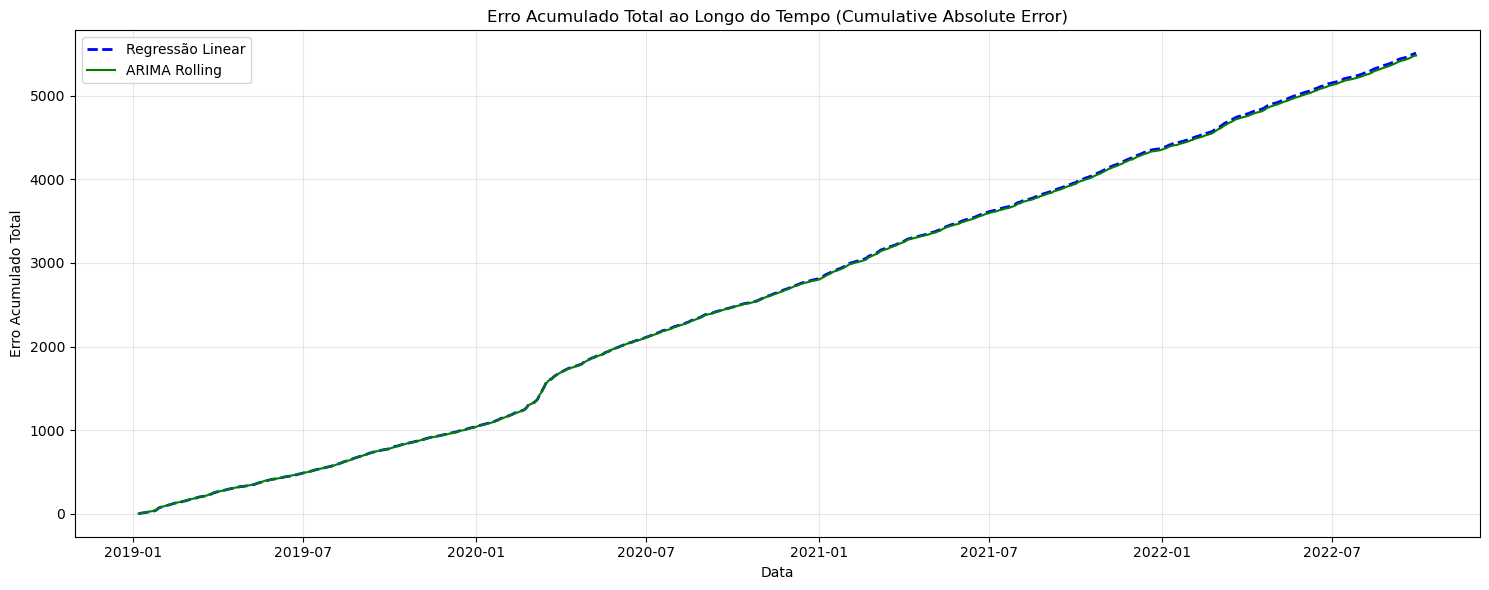

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Caminhos dos arquivos
csv_lr = "erro_acumulado_lr.csv"
csv_arima_rolling = "erro_acumulado_arima_rolling.csv"
csv_arima_base = "erro_acumulado_arima_base.csv"

# Carrega os dados
erro_lr = pd.read_csv(csv_lr, index_col=0, parse_dates=True).squeeze()
erro_arima_rolling = pd.read_csv(csv_arima_rolling, index_col=0, parse_dates=True).squeeze()
erro_arima_base = pd.read_csv(csv_arima_base, index_col=0, parse_dates=True).squeeze()

# Alinha os índices
common_index = erro_lr.index.intersection(erro_arima_rolling.index).intersection(erro_arima_base.index)
erro_lr = erro_lr.loc[common_index]
erro_arima_rolling = erro_arima_rolling.loc[common_index]
erro_arima_base = erro_arima_base.loc[common_index]

# Soma cumulativa (erro acumulado total ao longo do tempo)
erro_cum_lr = erro_lr.cumsum()
erro_cum_arima_rolling = erro_arima_rolling.cumsum()
erro_cum_arima_base = erro_arima_base.cumsum()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(common_index, erro_cum_lr, label="Regressão Linear", linestyle='--', color='blue', linewidth=2)
plt.plot(common_index, erro_cum_arima_rolling, label="ARIMA Rolling", linestyle='-', color='green')


plt.title("Erro Acumulado Total ao Longo do Tempo (Cumulative Absolute Error)")
plt.xlabel("Data")
plt.ylabel("Erro Acumulado Total")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()